In [ ]:
Data Generation:
We generate a synthetic dataset of 1,000 customers with random values for each feature.
Age, AnnualIncome, PurchaseFrequency, AvgOrderValue, DiscountSensitivity are numerical, while PreferredCategory is categorical (representing product preferences).
Data Preprocessing:
We scale the numerical data (using StandardScaler) to ensure all features contribute equally to the clustering.
Elbow Method:
We calculate WCSS (Within-Cluster Sum of Squares) for K values from 1 to 10 and plot it.
We look for the "elbow" point, which will help us select the optimal number of clusters. Ideally, this should be around K=3 or K=4, meaning after that point, the inertia (WCSS) will not decrease significantly.
K-Means Clustering:
We apply K-Means clustering with the optimal K (say K=4) and assign each customer to a cluster.
Cluster Insights:
We group the data by clusters and calculate the average values of each feature for each cluster. This will give us insights into the characteristics of each customer segment.
Cluster 0: Young customers with moderate income and moderate purchase frequency, but lower discount sensitivity.
Cluster 1: High-income, high-purchase frequency, discount-sensitive customers (ideal for promotional campaigns).
Cluster 2: Wealthy, high spenders, low discount sensitivity.
Cluster 3: Middle-income customers, moderate discount sensitivity, low purchase frequency.
K-Means uses (Euclidean) distance to measure the similarity between points. If features have different scales, those with larger values will dominate the clustering process, leading to biased clusters.
Example:
Feature A (salary): 50,000 to 1,00,000
Feature B (age): 20 to 60
Salary has a much larger range than age, so K-Means will give more importance to salary when computing distances.
To fix this, we scale the data to ensure all features contribute equally.


In [ ]:
Business Benefits of Clustering:
Personalized Marketing:
Based on the clusters, Flipkart can target customers with personalized marketing. For example, Cluster 1 can be targeted with discounts and promotions, while Cluster 2 can be offered premium products.
Improved Inventory Management:
By understanding which products appeal to which customer segments, Flipkart can optimize its inventory by focusing on the products that are popular among each cluster.
Customer Retention:
Clusters that exhibit high purchase frequency and discount sensitivity can be targeted for loyalty programs, while high-income clusters can be offered exclusive membership.
Sales Strategy:
High-value clusters can be offered up-selling opportunities (higher-end products), while price-sensitive clusters can receive discount-based promotions.
Conclusion:
This K-Means clustering approach can be applied to segment customers based on purchasing behavior, and the insights can be used to create targeted marketing strategies and improve business decisions. The process is simple and actionable, and the results are beneficial for optimizing customer experience and sales strategies.
Now for 30 customers:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
# Step 1: Generate synthetic dataset for Flipkart customers (Only 30 customers)
np.random.seed(42)

customer_count = 30

# Randomly generating data for features
age = np.random.randint(18, 65, customer_count)
annual_income = np.random.randint(300000, 1500000, customer_count)
purchase_frequency = np.random.randint(1, 20, customer_count)
avg_order_value = np.random.randint(500, 10000, customer_count)
preferred_category = np.random.choice(['Electronics', 'Fashion', 'HomeGoods', 'Groceries', 'Books'], customer_count)
discount_sensitivity = np.random.uniform(0.1, 1.0, customer_count)

In [4]:
# Create the dataframe
data = pd.DataFrame({
    'CustomerID': range(1, customer_count + 1),
    'Age': age,
    'AnnualIncome': annual_income,
    'PurchaseFrequency': purchase_frequency,
    'AvgOrderValue': avg_order_value,
    'PreferredCategory': preferred_category,
    'DiscountSensitivity': discount_sensitivity
})
data.head()

,CustomerID,Age,AnnualIncome,PurchaseFrequency,AvgOrderValue,PreferredCategory,DiscountSensitivity
0,1,56,456730,14,8506,Electronics,0.391911
1,2,46,1498079,17,3068,Fashion,0.209879
2,3,32,954811,4,5963,Fashion,0.420668
3,4,60,827035,18,2527,Groceries,0.916146
4,5,25,948143,8,3195,Books,0.344919


In [5]:
# Save the generated data to CSV
data.to_csv('flipkart_customers_30.csv', index=False)
print("Synthetic data for 30 customers saved to 'flipkart_customers_30.csv'.")

# Step 2: Preprocess the data (only numeric features for clustering)
numeric_data = data[['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

Synthetic data for 30 customers saved to 'flipkart_customers_30.csv'.


In [6]:
# Step 3: Elbow Method to determine the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

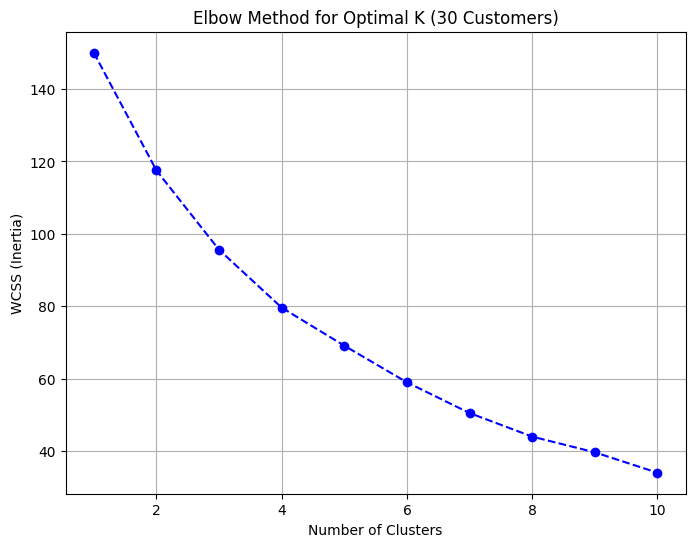

In [7]:
# Plot the Elbow Method to find the optimal K
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K (30 Customers)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [8]:
# Step 4: Apply K-Means with the selected number of clusters (K=3 or 4)
optimal_k = 3  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_data)

In [9]:
# Step 5: Show the first few rows of the dataset with cluster labels
print("\nClustered Data:")
print(data)


Clustered Data:
    CustomerID  Age  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0            1   56        456730                 14           8506   
1            2   46       1498079                 17           3068   
2            3   32        954811                  4           5963   
3            4   60        827035                 18           2527   
4            5   25        948143                  8           3195   
5            6   38        365725                  4           5758   
6            7   56       1478557                  2           6118   
7            8   36        384654                  6           7236   
8            9   40       1253277                 10            891   
9           10   28        891723                  4           6392   
10          11   28        619030                 18           4061   
11          12   41        855839                 12           6684   
12          13   53        573538                  2        

In [10]:
# Step 6: Cluster insights (mean of numeric features within each cluster)
numeric_columns = ['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']
cluster_insights = data.groupby('Cluster')[numeric_columns].mean()

In [11]:
# Display the cluster insights
print("\nCluster Insights (Average Features per Cluster):")
print(cluster_insights)


Cluster Insights (Average Features per Cluster):
               Age  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
Cluster                                                              
0        36.285714  9.072700e+05          15.714286    5398.142857   
1        44.125000  7.393701e+05           7.750000    7146.687500   
2        40.142857  1.009533e+06          12.428571    2359.857143   

         DiscountSensitivity  
Cluster                       
0                   0.791965  
1                   0.387120  
2                   0.273192  


In [12]:
# Save clustered data to CSV
data.to_csv('flipkart_clustered_customers_30.csv', index=False)
print("\nClustered data saved to 'flipkart_clustered_customers_30.csv'.")


Clustered data saved to 'flipkart_clustered_customers_30.csv'.


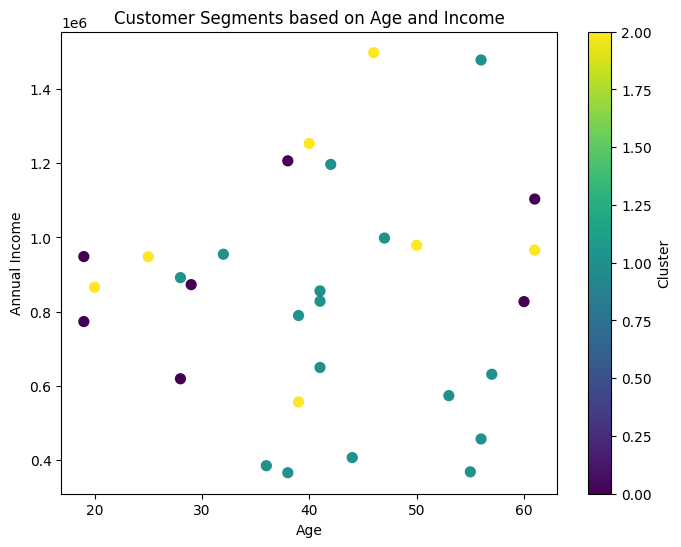

In [13]:
# Visualizing the clusters
plt.figure(figsize=(8, 6))
plt.scatter(data['Age'], data['AnnualIncome'], c=data['Cluster'], cmap='viridis', s=50)
plt.title('Customer Segments based on Age and Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# project2

Synthetic data saved to 'flipkart_customers_30.csv'.


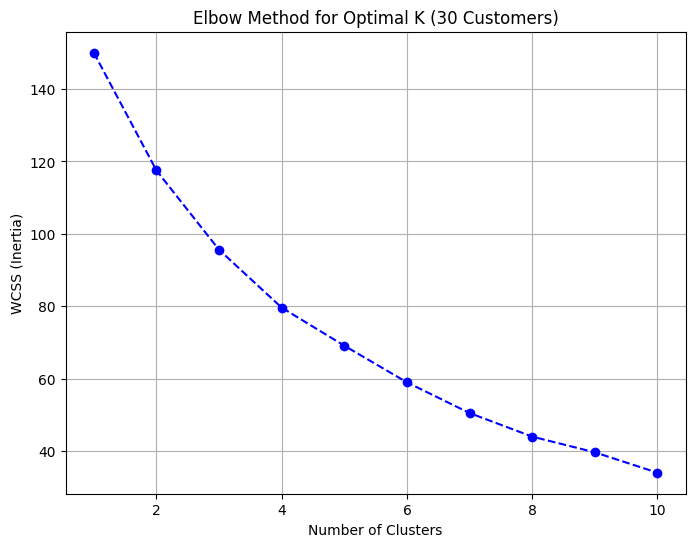


Clustered Data:
    CustomerID     Name  Age  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0            1    Aarav   56        456730                 14           8506   
1            2   Vihaan   46       1498079                 17           3068   
2            3   Ishaan   32        954811                  4           5963   
3            4    Kabir   60        827035                 18           2527   
4            5    Aryan   25        948143                  8           3195   
5            6    Anaya   38        365725                  4           5758   
6            7     Myra   56       1478557                  2           6118   
7            8   Aadhya   36        384654                  6           7236   
8            9     Siya   40       1253277                 10            891   
9           10     Riya   28        891723                  4           6392   
10          11     Neha   28        619030                 18           4061   
11          12    Rohan

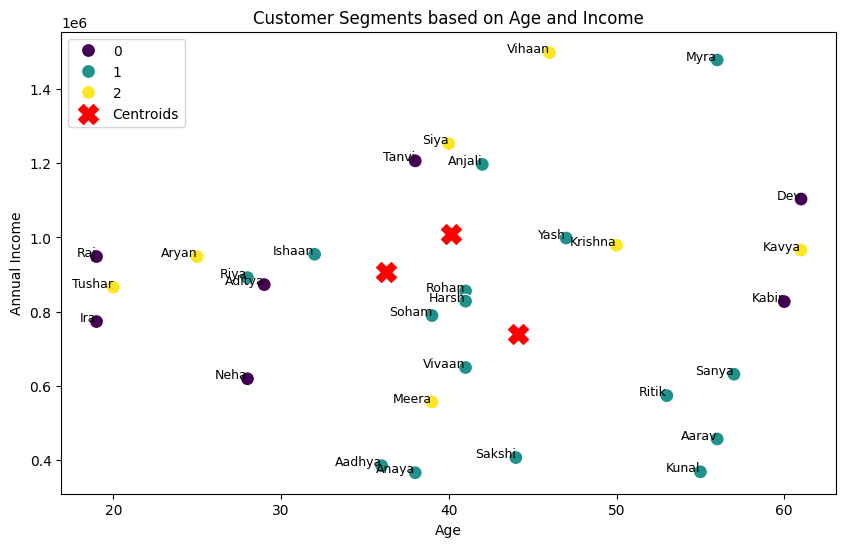

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Generate synthetic dataset for Flipkart customers (Only 30 customers)
np.random.seed(42)

customer_count = 30

# Sample Indian customer names
customer_names = [
    "Aarav", "Vihaan", "Ishaan", "Kabir", "Aryan", "Anaya", "Myra", "Aadhya", "Siya", "Riya",
    "Neha", "Rohan", "Ritik", "Sanya", "Harsh", "Tushar", "Soham", "Ira", "Vivaan", "Kavya",
    "Yash", "Kunal", "Raj", "Tanvi", "Krishna", "Aditya", "Meera", "Dev", "Anjali", "Sakshi"
]

# Generating random customer data
age = np.random.randint(18, 65, customer_count)
annual_income = np.random.randint(300000, 1500000, customer_count)
purchase_frequency = np.random.randint(1, 20, customer_count)
avg_order_value = np.random.randint(500, 10000, customer_count)
preferred_category = np.random.choice(['Electronics', 'Fashion', 'HomeGoods', 'Groceries', 'Books'], customer_count)
discount_sensitivity = np.random.uniform(0.1, 1.0, customer_count)

# Create DataFrame
data = pd.DataFrame({
    'CustomerID': range(1, customer_count + 1),
    'Name': customer_names,
    'Age': age,
    'AnnualIncome': annual_income,
    'PurchaseFrequency': purchase_frequency,
    'AvgOrderValue': avg_order_value,
    'PreferredCategory': preferred_category,
    'DiscountSensitivity': discount_sensitivity
})

# Save the generated data to CSV
data.to_csv('flipkart_customers_30.csv', index=False)
print("Synthetic data saved to 'flipkart_customers_30.csv'.")

# Step 2: Preprocess the data (only numeric features for clustering)
numeric_data = data[['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Step 3: Elbow Method to determine the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K (30 Customers)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# Step 4: Apply K-Means with the selected number of clusters (K=3 or 4)
optimal_k = 3  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_data)

# Step 5: Show the first few rows of the dataset with cluster labels
print("\nClustered Data:")
print(data)

# Step 6: Cluster insights (mean of numeric features within each cluster)
numeric_columns = ['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']
cluster_insights = data.groupby('Cluster')[numeric_columns].mean()

# Display the cluster insights
print("\nCluster Insights (Average Features per Cluster):")
print(cluster_insights)

# Save clustered data to CSV
data.to_csv('flipkart_clustered_customers_30.csv', index=False)
print("\nClustered data saved to 'flipkart_clustered_customers_30.csv'.")

# Step 7: Visualizing the Clusters (Age vs Annual Income)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=data['Age'], y=data['AnnualIncome'], hue=data['Cluster'], palette='viridis', s=100)

# Mark centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')

# Add customer names to points
for i in range(customer_count):
    plt.text(data['Age'][i], data['AnnualIncome'][i], data['Name'][i], fontsize=9, ha='right')

plt.title('Customer Segments based on Age and Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.legend()
plt.show()


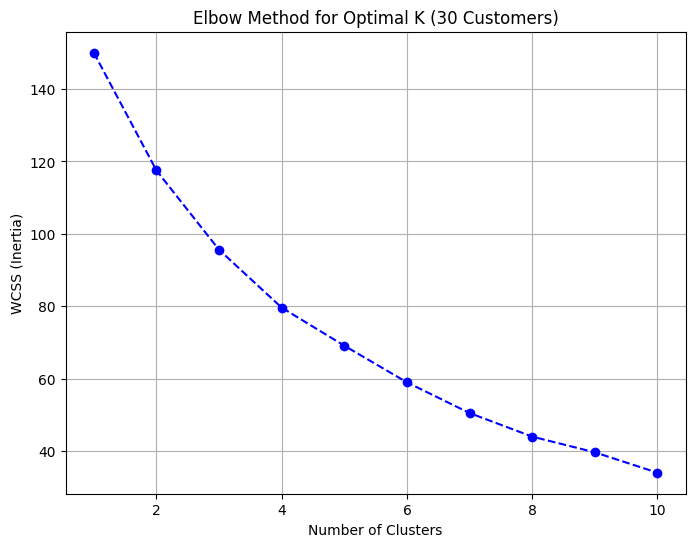


Clustered Data:
    CustomerID     Name  Age  AnnualIncome  PurchaseFrequency  AvgOrderValue  \
0            1    Aarav   56        456730                 14           8506   
1            2   Vihaan   46       1498079                 17           3068   
2            3   Ishaan   32        954811                  4           5963   
3            4    Kabir   60        827035                 18           2527   
4            5    Aryan   25        948143                  8           3195   
5            6    Anaya   38        365725                  4           5758   
6            7     Myra   56       1478557                  2           6118   
7            8   Aadhya   36        384654                  6           7236   
8            9     Siya   40       1253277                 10            891   
9           10     Riya   28        891723                  4           6392   
10          11     Neha   28        619030                 18           4061   
11          12    Rohan

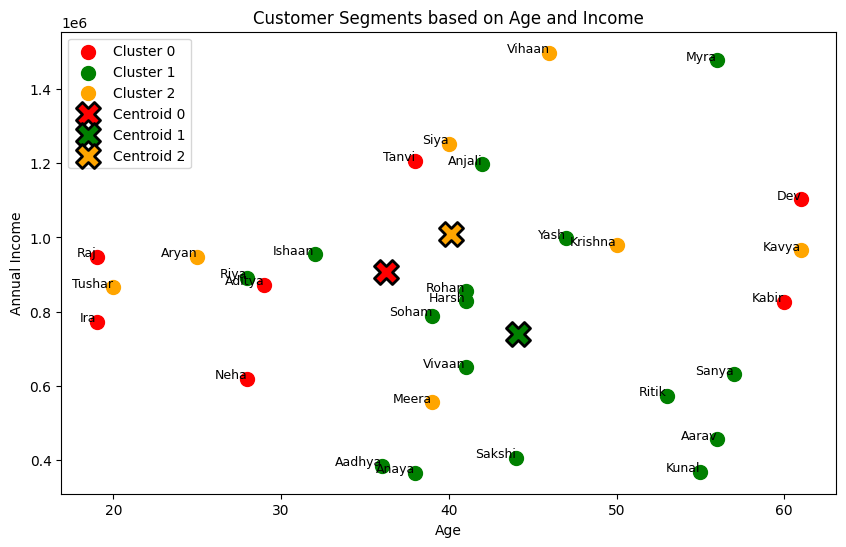

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Step 1: Generate synthetic dataset for Flipkart customers (Only 30 customers)
np.random.seed(42)

customer_count = 30

# Sample Indian customer names
customer_names = [
    "Aarav", "Vihaan", "Ishaan", "Kabir", "Aryan", "Anaya", "Myra", "Aadhya", "Siya", "Riya",
    "Neha", "Rohan", "Ritik", "Sanya", "Harsh", "Tushar", "Soham", "Ira", "Vivaan", "Kavya",
    "Yash", "Kunal", "Raj", "Tanvi", "Krishna", "Aditya", "Meera", "Dev", "Anjali", "Sakshi"
]

# Generating random customer data
age = np.random.randint(18, 65, customer_count)
annual_income = np.random.randint(300000, 1500000, customer_count)
purchase_frequency = np.random.randint(1, 20, customer_count)
avg_order_value = np.random.randint(500, 10000, customer_count)
preferred_category = np.random.choice(['Electronics', 'Fashion', 'HomeGoods', 'Groceries', 'Books'], customer_count)
discount_sensitivity = np.random.uniform(0.1, 1.0, customer_count)

# Create DataFrame
data = pd.DataFrame({
    'CustomerID': range(1, customer_count + 1),
    'Name': customer_names,
    'Age': age,
    'AnnualIncome': annual_income,
    'PurchaseFrequency': purchase_frequency,
    'AvgOrderValue': avg_order_value,
    'PreferredCategory': preferred_category,
    'DiscountSensitivity': discount_sensitivity
})

# Step 2: Preprocess the data (only numeric features for clustering)
numeric_data = data[['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']]

# Standardize the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_data)

# Step 3: Elbow Method to determine the optimal number of clusters (K)
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K (30 Customers)')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# Step 4: Apply K-Means with the selected number of clusters (K=3)
optimal_k = 3  # Adjust based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
data['Cluster'] = kmeans.fit_predict(scaled_data)

# Step 5: Show the first few rows of the dataset with cluster labels
print("\nClustered Data:")
print(data)

# Step 6: Cluster insights (mean of numeric features within each cluster)
numeric_columns = ['Age', 'AnnualIncome', 'PurchaseFrequency', 'AvgOrderValue', 'DiscountSensitivity']
cluster_insights = data.groupby('Cluster')[numeric_columns].mean()

# Display the cluster insights
print("\nCluster Insights (Average Features per Cluster):")
print(cluster_insights)

# Step 7: Visualizing the Clusters (Age vs Annual Income)
plt.figure(figsize=(10, 6))

# Define distinct colors for clusters
cluster_colors = {0: 'red', 1: 'green', 2: 'orange'}  # Red, Green, Yellow/Orange

# Scatter plot of customers
for cluster, color in cluster_colors.items():
    cluster_data = data[data['Cluster'] == cluster]
    plt.scatter(cluster_data['Age'], cluster_data['AnnualIncome'], color=color, s=100, label=f'Cluster {cluster}')

# Mark centroids with the SAME colors as their respective clusters
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], marker='X', s=300, color=cluster_colors[i], edgecolors='black', linewidth=2, label=f'Centroid {i}')

# Add customer names to points
for i in range(customer_count):
    plt.text(data['Age'][i], data['AnnualIncome'][i], data['Name'][i], fontsize=9, ha='right')

plt.title('Customer Segments based on Age and Income')
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.legend()
plt.show()

In [ ]:
📊 Business Insights
1️⃣ Cluster 0 (🔴 Young Budget Shoppers) → Frequent buyers but low spending. Send them more discounts.
2️⃣ Cluster 1 (🟢 High-Value Buyers) → They buy less often but spend a lot. Recommend premium products.
3️⃣ Cluster 2 (🟠 Balanced Regular Customers) → Medium frequency & spending. Offer personalized deals.
Display Well -- Business Insights

# THE END